Kaons: 350-650 MeV (disable ‘picky-match’ condition for more potential Kaon events); ~ 3420 events

In [1]:
import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from tqdm import tqdm

In [2]:
RAW_KAONS = '/Volumes/easystore/proton-kaon/raw/rawExtracted_350_650.root'

In [3]:
file = uproot.open(RAW_KAONS)
file.keys()

['ana;1', 'ana/raw;352', 'ana/raw;351']

In [4]:
tree = file['ana/raw;352']
tree.show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
run                  | int32_t                  | AsDtype('>i4')
subrun               | int32_t                  | AsDtype('>i4')
event                | int32_t                  | AsDtype('>i4')
evttime              | double                   | AsDtype('>f8')
raw_rawadc           | std::vector<int16_t>     | AsJagged(AsDtype('>i2'), he...
raw_channel          | std::vector<uint32_t>    | AsJagged(AsDtype('>u4'), he...


In [5]:
tree.num_entries

20035

In [7]:
file = RAW_KAONS
tree = uproot.open(file)["ana/raw;352"]

n = tree.num_entries   

run    = tree["run"].array(library="np")
subrun = tree["subrun"].array(library="np")
event  = tree["event"].array(library="np")

events_df = pd.DataFrame({
    "file_path": [file] * n,
    "event_index": list(range(n)),
    "run": run,
    "subrun": subrun,
    "event": event,
})

events_df

,file_path,event_index,run,subrun,event
0,/Volumes/easystore/proton-kaon/raw/rawExtracte...,0,8557,4,456
1,/Volumes/easystore/proton-kaon/raw/rawExtracte...,1,8557,7,610
2,/Volumes/easystore/proton-kaon/raw/rawExtracte...,2,8557,11,784
3,/Volumes/easystore/proton-kaon/raw/rawExtracte...,3,8557,15,983
4,/Volumes/easystore/proton-kaon/raw/rawExtracte...,4,8557,33,1754
...,...,...,...,...,...
20030,/Volumes/easystore/proton-kaon/raw/rawExtracte...,20030,9788,305,26735
20031,/Volumes/easystore/proton-kaon/raw/rawExtracte...,20031,9788,305,26737
20032,/Volumes/easystore/proton-kaon/raw/rawExtracte...,20032,9788,307,26859
20033,/Volumes/easystore/proton-kaon/raw/rawExtracte...,20033,9788,309,27031


In [10]:
events_df.query('run == 613')

,file_path,event_index,run,subrun,event


In [11]:
def display(index, save=False):
    
    i = index

    data = tree.arrays(
    ["rawadc1", "run", "subrun", "event"],
    entry_start=i,
    entry_stop=i+1,
    library="ak",
    )

    run = ak.to_numpy(data[0]["run"])[0]
    subrun = ak.to_numpy(data[0]["subrun"])[0]
    event = ak.to_numpy(data[0]["event"])[0]

    adc_data = ak.to_numpy(data[0]["rawadc1"])

    num_channels_in_event = 480 
    num_ticks = len(adc_data) // num_channels_in_event 
    num_channels_in_event, num_ticks


    adc_data2d = adc_data.reshape((num_channels_in_event, num_ticks)) 

    collection = adc_data2d[240:, :]
    induction = adc_data2d[:240, :]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5))

    sns.heatmap(collection.T, cmap="viridis", cbar_kws={'label': 'ADC Counts'}, ax=ax1)
    ax1.set_xlabel("Collection Plane Wire Number (0-239)")
    ax1.set_ylabel("Time Tick")
    ax1.set_title("Collection Plane")
    ax1.invert_yaxis()

    sns.heatmap(induction.T, cmap='viridis', cbar_kws={'label': 'ADC Counts'}, ax=ax2)
    ax2.set_xlabel("Induction Plane Wire Number (0-239)")
    ax2.set_ylabel("Time Tick")
    ax2.set_title("Induction Plane")
    ax2.invert_yaxis()

    if save:
        plt.savefig(f'/Volumes/easystore/kaondisplays/kaon_{run}_{subrun}_{event}.png', dpi=100)
        plt.close(fig)
    else:
        return

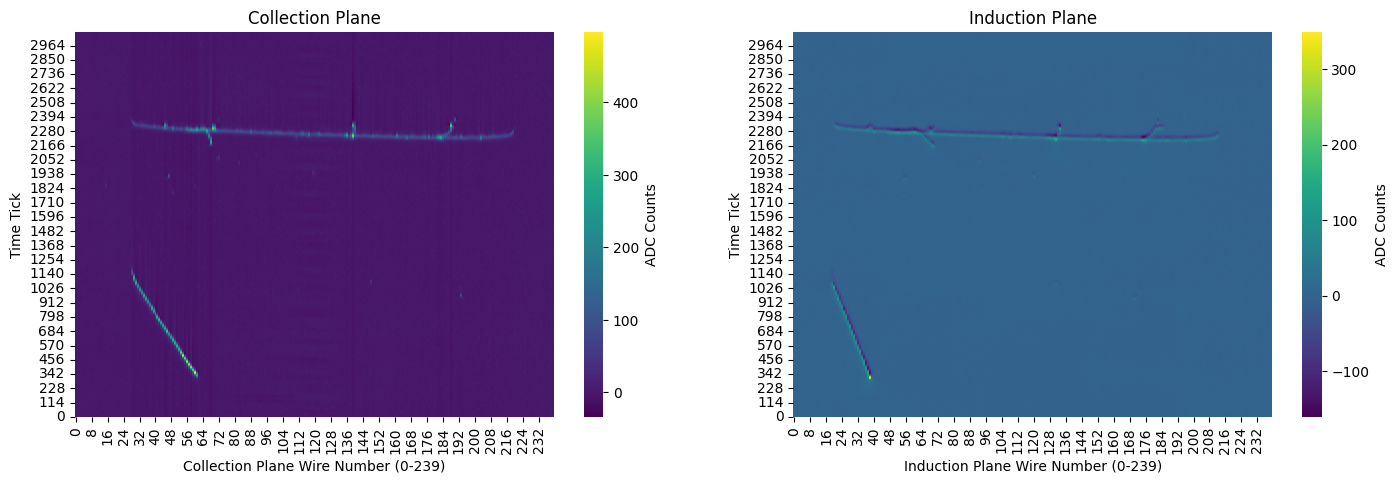

In [40]:
display(29)

# Picky / Match labels

In [11]:
df = pd.read_csv("/Volumes/easystore/proton-deuteron/csv/picky+match.csv")

In [12]:
pmkaons = pd.merge(df,
                   events_df,
                   on=['run', 'subrun', 'event'],
                   how='inner')

In [13]:
pmkaons

,run,subrun,event,p,m,beamline_mass,file_path,event_index
0,8675,30,3371,1,0,452.18,/Volumes/easystore/RAW_Kaon_AnaTree.root,888
1,8675,82,8656,1,0,398.26,/Volumes/easystore/RAW_Kaon_AnaTree.root,893
2,8675,95,9901,1,0,453.03,/Volumes/easystore/RAW_Kaon_AnaTree.root,894
3,8675,135,14407,1,0,408.31,/Volumes/easystore/RAW_Kaon_AnaTree.root,899
4,8675,136,14542,1,0,537.30,/Volumes/easystore/RAW_Kaon_AnaTree.root,900
...,...,...,...,...,...,...,...,...
3550,9780,46,7029,1,0,450.74,/Volumes/easystore/RAW_Kaon_AnaTree.root,3485
3551,9781,2,1065,1,0,399.96,/Volumes/easystore/RAW_Kaon_AnaTree.root,3489
3552,9781,12,2617,1,1,566.33,/Volumes/easystore/RAW_Kaon_AnaTree.root,3490
3553,9781,49,8480,1,0,439.40,/Volumes/easystore/RAW_Kaon_AnaTree.root,3493


In [14]:
pmkaons[(pmkaons['p'] == 1)]

,run,subrun,event,p,m,beamline_mass,file_path,event_index
0,8675,30,3371,1,0,452.18,/Volumes/easystore/RAW_Kaon_AnaTree.root,888
1,8675,82,8656,1,0,398.26,/Volumes/easystore/RAW_Kaon_AnaTree.root,893
2,8675,95,9901,1,0,453.03,/Volumes/easystore/RAW_Kaon_AnaTree.root,894
3,8675,135,14407,1,0,408.31,/Volumes/easystore/RAW_Kaon_AnaTree.root,899
4,8675,136,14542,1,0,537.30,/Volumes/easystore/RAW_Kaon_AnaTree.root,900
...,...,...,...,...,...,...,...,...
3550,9780,46,7029,1,0,450.74,/Volumes/easystore/RAW_Kaon_AnaTree.root,3485
3551,9781,2,1065,1,0,399.96,/Volumes/easystore/RAW_Kaon_AnaTree.root,3489
3552,9781,12,2617,1,1,566.33,/Volumes/easystore/RAW_Kaon_AnaTree.root,3490
3553,9781,49,8480,1,0,439.40,/Volumes/easystore/RAW_Kaon_AnaTree.root,3493


In [15]:
pmkaons[(pmkaons['p'] == 1) & (pmkaons['m'] == 1)]

,run,subrun,event,p,m,beamline_mass,file_path,event_index
6,8675,169,18577,1,1,549.86,/Volumes/easystore/RAW_Kaon_AnaTree.root,904
13,8675,262,30124,1,1,572.88,/Volumes/easystore/RAW_Kaon_AnaTree.root,917
16,8766,114,14224,1,1,489.59,/Volumes/easystore/RAW_Kaon_AnaTree.root,1745
23,8675,229,26068,1,1,560.91,/Volumes/easystore/RAW_Kaon_AnaTree.root,914
28,8766,252,31108,1,1,509.26,/Volumes/easystore/RAW_Kaon_AnaTree.root,1754
...,...,...,...,...,...,...,...,...
3537,9787,34,3446,1,1,478.13,/Volumes/easystore/RAW_Kaon_AnaTree.root,3521
3543,9780,71,10909,1,1,492.50,/Volumes/easystore/RAW_Kaon_AnaTree.root,3487
3547,9781,60,10214,1,1,387.00,/Volumes/easystore/RAW_Kaon_AnaTree.root,3494
3548,9781,104,17211,1,1,524.33,/Volumes/easystore/RAW_Kaon_AnaTree.root,3496


In [7]:
import matplotlib
matplotlib.use('Agg')

savedir = '/Volumes/easystore/kaondisplays'

for i in tqdm(range(tree.num_entries), desc='Saving displays', unit='evt'):
    data = tree.arrays(
        ["rawadc1", "run", "subrun", "event"],
        entry_start=i, entry_stop=i+1, library="ak"
    )
    row = data[0]
    r, s, e = int(row["run"]), int(row["subrun"]), int(row["event"])
    adc = ak.to_numpy(row["rawadc1"])
    
    n_ch = 480
    n_ticks = len(adc) // n_ch
    adc2d = adc.reshape((n_ch, n_ticks))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5))
    
    ax1.imshow(adc2d[240:].T, aspect='auto', origin='lower', cmap='viridis')
    ax1.set_xlabel("Collection Plane Wire Number (0-239)")
    ax1.set_ylabel("Time Tick")
    ax1.set_title("Collection Plane")
    
    ax2.imshow(adc2d[:240].T, aspect='auto', origin='lower', cmap='viridis')
    ax2.set_xlabel("Induction Plane Wire Number (0-239)")
    ax2.set_ylabel("Time Tick")
    ax2.set_title("Induction Plane")
    
    fig.savefig(f'{savedir}/kaon_{r}_{s}_{e}.png', dpi=100, bbox_inches='tight')
    plt.close(fig)

Saving displays: 100%|██████████| 3567/3567 [11:53<00:00,  5.00evt/s]


In [13]:
import pandas as pd
import matplotlib
matplotlib.use("Agg")

selected = (
    pd.read_csv("selected_kaons.csv")
    .drop(columns=["Unnamed: 0"], errors="ignore")
)

selected_events = (
    selected.merge(
        events_df[["event_index", "run", "subrun", "event"]],
        on=["run", "subrun", "event"],
        how="inner",
    )
    .drop_duplicates(subset="event_index")
    .sort_values("event_index")
)

print(f"Saving {len(selected_events)} selected events")

for idx in tqdm(selected_events["event_index"], desc="Saving selected kaon displays", unit="evt"):
    display(int(idx), save=True)


Saving 802 selected events


Saving selected kaon displays: 100%|██████████| 802/802 [12:28<00:00,  1.07evt/s]
